# Transfer Learning con MobileNetV2 e Interpretabilidad (Grad-CAM) para Reconocimiento de Expresiones Faciales (FER-2013)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Profundo (59003) — MIA-B
**Semana 3 — Práctica Grupal (Ejercicio Práctico Clase 3)**
**Grupo 5**
**Profesor:** J. Rodriguez Chivata
**Integrantes:** J. Quizamánchuro Fuel, G. Calahorrano Guayasamin, D. Perez Cedillo

---

## Resumen del trabajo

Este notebook implementa **Transfer Learning con `MobileNetV2`** (pre-entrenada en ImageNet) sobre el dataset **FER-2013** — el mismo dataset usado en la Semana 2 — y aplica **Grad-CAM (Gradient-weighted Class Activation Mapping)** como técnica de explicabilidad para entender qué regiones de la cara está usando el modelo para tomar cada decisión.

El experimento sigue las dos fases canónicas del Transfer Learning:

1. **Feature Extraction:** congelar todo el backbone pre-entrenado y entrenar solo una cabeza de clasificación nueva (12 épocas).
2. **Fine-Tuning:** descongelar los últimos 20 bloques del backbone y re-entrenar con un *learning rate* 1000× más bajo para refinar pesos sin destruir lo aprendido en ImageNet (12 épocas adicionales).

Tres comparaciones se reportan al final: (a) CNN entrenada desde cero (Semana 2), (b) Transfer Learning con backbone congelado, (c) Modelo después del fine-tuning.

### Motivación profesional

La conexión con **Psico Platform** se mantiene: un clasificador de expresiones faciales más preciso y, sobre todo, **interpretable** (que pueda mostrar *por qué* clasifica como `happy` o `sad`) es directamente aplicable a herramientas de psicoeducación asistida. Grad-CAM convierte la decisión del modelo en una visualización que un psicólogo puede examinar y validar — un requisito clínico cuando se asisten decisiones sobre el estado afectivo de un usuario.


## 1. Aplicación del feedback acumulado de las Semanas 1 y 2

Esta entrega responde explícitamente a las tres observaciones puntuales acumuladas del docente:

| Feedback | Origen | Aplicación en esta entrega |
|---|---|---|
| *"Trabajar más del lado de las características; OHE no es la solución"* | Semana 1 | **MobileNetV2 aporta features ya aprendidas** sobre 1,4 M imágenes naturales de ImageNet. La cabeza nueva trabaja sobre 1.280 features extraídas, no sobre píxeles crudos. Es el extremo opuesto del OHE manual. |
| *"Quitar MaxPooling porque la imagen es 48×48×1 (poca información)"* | Semana 2 | **MobileNetV2 no usa MaxPooling** — usa convoluciones con `stride=2` y *depthwise separable convolutions*. El backbone elegido respeta este principio. Adicionalmente, redimensionamos a **96×96 RGB** para entregar más información a la red. |
| *"Esta semana podrían expandir más la exploración con fine-tuning y redes más grandes"* | Semana 2 | **Esta es la respuesta directa.** Toda la entrega es fine-tuning sobre una red grande (~3,4 M parámetros entrenables totales, con un backbone de 88 capas). |

> **Nota de calibración (lección aplicada desde Semanas 1 y 2):** la entrega usa `learning_rate` diferenciado por fase (1e-3 en feature extraction, 1e-5 en fine-tuning), `EarlyStopping(patience=5)` y `ReduceLROnPlateau`. Estas defensas vienen de las lecciones de calibración acumuladas en las semanas previas — los hiperparámetros se calibran al problema, no se asumen.


## 2. Configuración del entorno y carga de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
)

# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

# Estilo gráficos (coherente con Semanas 1 y 2)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')


TensorFlow: 2.16.2
Keras:      3.14.1


In [2]:
# Detección de aceleración por hardware
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU(s) detectada(s): {len(gpus)}')
    for g in gpus:
        print(f'  → {g.name} ({g.device_type})')
    print('\nKeras usará Metal Performance Shaders automáticamente.')
else:
    print('Sin GPU detectada — se usará CPU. El entrenamiento será notablemente más lento.')


GPU(s) detectada(s): 1
  → /physical_device:GPU:0 (GPU)

Keras usará Metal Performance Shaders automáticamente.


## 3. Selección y justificación del modelo pre-entrenado

### Backbone elegido: `MobileNetV2` (pre-entrenado en ImageNet)

**MobileNetV2** (Sandler et al., 2018) es una arquitectura convolucional diseñada para dispositivos móviles. Es la elección óptima para esta tarea por cinco razones:

| Criterio | MobileNetV2 | Alternativa descartada |
|---|---|---|
| **Tamaño** | ~3,5 M parámetros | ResNet50: 25 M (sobre-dimensionado para 48×48) |
| **Profundidad** | 88 capas, 17 bloques *inverted residual* | VGG16: solo 16 capas, más pesado |
| **Hardware target** | Eficiente en M1 Max (operaciones depthwise) | EfficientNet: más complejo de adaptar |
| **Input mínimo** | 96×96 (admite input pequeño) | InceptionV3: requiere 299×299 (upscale agresivo) |
| **Sin MaxPooling** | Usa `stride=2` en bloques convolucionales | Cumple feedback Semana 2 al pie de la letra |

### Análisis del modelo original

- **Dataset de pre-entrenamiento:** ImageNet (1,4 M imágenes, 1.000 clases). Las features aprendidas (bordes orientados, texturas, partes de objetos, configuraciones) son **transferibles a otros dominios visuales** — incluyendo rostros humanos, aunque ImageNet no fue especializado en caras.
- **Arquitectura interna:** *Inverted Residual Blocks* con *depthwise separable convolutions* — separan convolución espacial de la combinación entre canales, reduciendo cómputo 8-9× sin perder accuracy significativa.
- **Acceso en Keras:** `tf.keras.applications.MobileNetV2(weights='imagenet')`.

### Vínculo con el problema

FER-2013 (48×48 grayscale, 7 clases) tiene tres mismatches con ImageNet (224×224 RGB, 1000 clases) que abordaremos en la Sección 4:

1. **Resolución:** ImageNet ≥ 224, FER ≈ 48 → upscale a 96×96.
2. **Canales:** ImageNet RGB, FER grayscale → replicar canal a 3.
3. **Normalización:** MobileNetV2 espera `[-1, +1]` específicamente → `preprocess_input` de la API.

El tamaño moderado del backbone (3,5 M parámetros) es coherente con un dataset también moderado (28.709 imágenes train). Backbones mayores (ResNet50, EfficientNetB7) sobre-ajustarían rápidamente.


## 4. Adaptación del dataset y ficha técnica

Las imágenes FER-2013 vienen en `data/{train,test}/{clase}/*.jpg`. Para alimentar `MobileNetV2` se aplican **tres transformaciones encadenadas**:

1. **Redimensionado** 48×48 → 96×96 (interpolación bilineal por defecto en `image_dataset_from_directory`).
2. **Replicación de canal** grayscale → RGB (canal único copiado a 3 canales — patrón estándar cuando se usa un backbone RGB sobre datos monocromáticos).
3. **Normalización específica del backbone** con `mobilenet_v2.preprocess_input`, que escala los píxeles de `[0, 255]` a `[-1, +1]`.

La pipeline `tf.data` aplica todo lo anterior con `cache().prefetch(AUTOTUNE)` para mantener la GPU alimentada — clave en M1/Metal donde el bottleneck de E/S es real.


In [3]:
DATA_DIR  = Path('data')
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'

def class_counts(folder: Path) -> pd.Series:
    counts = {d.name: sum(1 for _ in d.iterdir())
              for d in sorted(folder.iterdir()) if d.is_dir()}
    return pd.Series(counts).sort_values(ascending=False)

train_counts = class_counts(TRAIN_DIR)
test_counts  = class_counts(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Test': test_counts})
df_counts.loc['TOTAL'] = df_counts.sum()
df_counts['% Train'] = (df_counts['Train'] / df_counts.loc['TOTAL', 'Train'] * 100).round(2)
print(df_counts)


          Train  Test  % Train
angry      3995   958    13.92
disgust     436   111     1.52
fear       4097  1024    14.27
happy      7215  1774    25.13
neutral    4965  1233    17.29
sad        4830  1247    16.82
surprise   3171   831    11.05
TOTAL     28709  7178   100.00


In [4]:
# Hiperparámetros del pipeline
IMG_SIZE_NATIVE = (48, 48)
IMG_SIZE_TL     = (96, 96)    # MobileNetV2 admite >= 32; 96 es el balance velocidad/calidad
BATCH_SIZE      = 64
AUTOTUNE        = tf.data.AUTOTUNE
NUM_CLASSES     = 7

# Cargar imágenes en grayscale 48x48
train_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset='training',
    seed=SEED,
    color_mode='grayscale',
    image_size=IMG_SIZE_NATIVE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset='validation',
    seed=SEED,
    color_mode='grayscale',
    image_size=IMG_SIZE_NATIVE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    color_mode='grayscale',
    image_size=IMG_SIZE_NATIVE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

CLASS_NAMES = train_ds_raw.class_names
print(f'\nClases ({NUM_CLASSES}): {CLASS_NAMES}')


Found 28709 files belonging to 7 classes.


Using 24403 files for training.


2026-06-02 21:43:30.481100: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-06-02 21:43:30.481319: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-02 21:43:30.481339: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-06-02 21:43:30.481425: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-02 21:43:30.481461: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 28709 files belonging to 7 classes.


Using 4306 files for validation.


Found 7178 files belonging to 7 classes.



Clases (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# Pipeline de adaptación: 48x48x1 grayscale → 96x96x3 RGB + preprocess_input
def adapt_for_mobilenet(images, labels):
    # Resize a 96x96
    images = tf.image.resize(images, IMG_SIZE_TL, method='bilinear')
    # Grayscale (1 canal) → RGB (3 canales) replicando
    images = tf.image.grayscale_to_rgb(images)
    # Cast a float32 y aplicar normalización específica de MobileNetV2 ([-1, +1])
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

train_ds = train_ds_raw.map(adapt_for_mobilenet, num_parallel_calls=AUTOTUNE).cache().shuffle(1024, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(adapt_for_mobilenet, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(adapt_for_mobilenet, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# Verificación: forma y rango
batch_imgs, batch_labels = next(iter(train_ds))
print(f'\nForma de batch tras adaptación: {batch_imgs.shape}  (esperado: ({BATCH_SIZE}, 96, 96, 3))')
print(f'Rango de píxeles: [{tf.reduce_min(batch_imgs).numpy():.3f}, {tf.reduce_max(batch_imgs).numpy():.3f}]  (esperado: ≈[-1, +1])')
print(f'Dtype: {batch_imgs.dtype}')



Forma de batch tras adaptación: (64, 96, 96, 3)  (esperado: (64, 96, 96, 3))
Rango de píxeles: [-1.000, 1.000]  (esperado: ≈[-1, +1])
Dtype: <dtype: 'float32'>


### Ficha técnica resumida

| Atributo | Valor |
|---|---|
| Imágenes totales | 35.887 (28.709 train / 7.178 test) |
| Split train/val | 85 % / 15 % (semilla 42, estratificado por directorio) |
| Resolución nativa | 48 × 48 grayscale |
| Resolución tras adaptación | 96 × 96 RGB |
| Normalización | `mobilenet_v2.preprocess_input` ⇒ `[-1, +1]` |
| Batch size | 64 |
| Clases | 7 (`angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`) |
| Clase mayoritaria | `happy` (7.215) |
| Clase minoritaria | `disgust` (436) — ratio 16,5 : 1 |
| Pipeline | `tf.data` con `cache + prefetch(AUTOTUNE)` |


## 5. Estrategia de Transfer Learning y Fine-Tuning

### Modificación de la arquitectura

El modelo final es la composición de tres bloques:

```
Input(96, 96, 3, preprocessed)
    ↓
[ MobileNetV2 backbone, weights='imagenet', include_top=False ]    ← 2,2 M params, congelable
    ↓ output shape: (3, 3, 1280)
[ GlobalAveragePooling2D ]                                          ← convierte mapa espacial en vector
    ↓ output shape: (1280,)
[ Dropout(0.3) → Dense(128, ReLU) → Dropout(0.2) → Dense(7, softmax) ]  ← cabeza nueva, ~165k params
```

**Decisiones del head:**
- `GlobalAveragePooling2D` en vez de `Flatten`: drásticamente menos parámetros (1.280 vs 11.520), menos sobre-ajuste con un dataset moderado.
- `Dense(128)` intermedia: capacidad suficiente para mapear 1.280 features a 7 clases sin colapsar.
- Dropout `0.3 / 0.2`: calibrado en línea con las lecciones de Semana 2 (donde dropout 0.5 produjo underfitting).

### Estrategia de congelamiento — dos fases

**Fase 1 — Feature Extraction (backbone 100 % congelado):**
- `backbone.trainable = False` → solo se actualizan los pesos de la cabeza nueva.
- Objetivo: aprender a *mapear* las features pre-existentes a nuestras 7 clases sin tocar el backbone (sus pesos están afinados para 1.000 clases de ImageNet y no queremos destruirlos en las primeras épocas con gradientes grandes).
- `learning_rate = 1e-3` (Adam) — agresivo porque solo entrenamos ~165k parámetros simples.
- 12 épocas con `EarlyStopping(patience=5, restore_best_weights=True)`.

**Fase 2 — Fine-Tuning (descongelar últimos 20 bloques):**
- `backbone.trainable = True`, pero **se congelan todas las capas excepto las últimas 20**. Las capas iniciales aprendieron features de bajo nivel (bordes, texturas) — válidas universalmente. Las capas finales son más específicas y se benefician de ajuste fino al dominio de rostros.
- `learning_rate = 1e-5` (Adam) — **1000× más bajo** que la fase 1. Esto es crítico: con LR alto destruiríamos los pesos pre-entrenados. La rúbrica menciona explícitamente "tasas de aprendizaje diferenciadas o reducidas para evitar la destrucción de los pesos pre-entrenados".
- 12 épocas adicionales con mismos callbacks.

Esta estrategia es el patrón canónico documentado en la guía oficial de TensorFlow ([Transfer learning and fine-tuning](https://www.tensorflow.org/tutorials/images/transfer_learning)).


In [6]:
def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE_TL):
    """Backbone MobileNetV2 pre-entrenado + cabeza nueva."""
    # Backbone — sin las capas top (clasificación de ImageNet)
    backbone = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False  # congelar por defecto

    # Construcción del modelo completo
    inputs = keras.Input(shape=(*img_size, 3), name='entrada')
    x = backbone(inputs, training=False)             # importante: training=False mantiene BN en modo inferencia
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)
    x = layers.Dense(128, activation='relu', name='dense_head')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='salida')(x)

    model = keras.Model(inputs, outputs, name='mobilenetv2_fer_tl')
    return model, backbone

model, backbone = build_model()
print(f'Parámetros totales:           {model.count_params():>10,}')
print(f'Parámetros entrenables:       {sum(tf.size(w).numpy() for w in model.trainable_weights):>10,}')
print(f'Parámetros no entrenables:    {sum(tf.size(w).numpy() for w in model.non_trainable_weights):>10,}')


Parámetros totales:            2,422,855
Parámetros entrenables:          164,871
Parámetros no entrenables:     2,257,984


In [7]:
model.summary()

Model: "mobilenetv2_fer_tl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Fase 1 — Feature Extraction (backbone congelado)

Compilación con `Adam(lr=1e-3)`, pérdida `sparse_categorical_crossentropy` (etiquetas enteras — coherente con el feedback "menos OHE" de Semana 1).


In [8]:
import json

MODEL_PATH             = 'outputs/modelo_mobilenetv2_finetuned.keras'   # post-Fase 2 (final)
MODEL_POST_PHASE1_PATH = 'outputs/modelo_post_phase1.keras'              # post-Fase 1 (TL puro)
HIST_1_PATH = 'outputs/history_phase_1.json'
HIST_2_PATH = 'outputs/history_phase_2.json'

LR_PHASE_1 = 1e-3
EPOCHS_PHASE_1 = 12

# Helper para no entrenar dos veces si ya hay modelo + history persistidos
class CachedHistory:
    def __init__(self, hist_dict): self.history = hist_dict

# Para skip-training necesitamos AMBOS modelos guardados (intermedio + final) — sección 13 los compara
ALL_CACHED = all(Path(p).exists() for p in [MODEL_PATH, MODEL_POST_PHASE1_PATH, HIST_1_PATH, HIST_2_PATH])

if ALL_CACHED:
    print(f'✓ Modelo final, modelo intermedio (TL puro) e histories ya persistidos — cargando sin re-entrenar.')
    model = keras.models.load_model(MODEL_PATH)
    with open(HIST_1_PATH) as f:
        history_phase_1 = CachedHistory(json.load(f))
    # Re-localizar backbone dentro del modelo cargado (necesario para fase 2 y Grad-CAM)
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            backbone = layer
            break
    print(f'  → Backbone re-localizado: {backbone.name}')
    print(f'  → Épocas en history: {len(history_phase_1.history["loss"])}')
else:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE_1),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    callbacks_phase_1 = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1,
        ),
    ]

    print(f'Entrenando Fase 1 — Feature Extraction ({EPOCHS_PHASE_1} épocas, lr={LR_PHASE_1})...')
    history_phase_1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE_1,
        callbacks=callbacks_phase_1,
        verbose=2,
    )
    print(f'\n✓ Fase 1 completada en {len(history_phase_1.history["loss"])} épocas.')

    # Persistir history para evitar re-entrenamiento en iteraciones futuras
    with open(HIST_1_PATH, 'w') as f:
        json.dump(history_phase_1.history, f)
    print(f'✓ History de Fase 1 guardada en {HIST_1_PATH}')

    # IMPORTANTE: guardar el modelo INTERMEDIO (post-Fase-1, antes del fine-tuning).
    # Esto permite evaluar TL puro vs Fine-Tuning en la Sección 13 sin re-entrenar.
    model.save(MODEL_POST_PHASE1_PATH)
    print(f'✓ Modelo intermedio (TL puro) guardado en {MODEL_POST_PHASE1_PATH}')

Entrenando Fase 1 — Feature Extraction (12 épocas, lr=0.001)...
Epoch 1/12


2026-06-02 21:43:36.316683: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


382/382 - 24s - 64ms/step - accuracy: 0.2860 - loss: 2.9649 - val_accuracy: 0.4494 - val_loss: 1.7508 - learning_rate: 0.0010


Epoch 2/12


382/382 - 15s - 40ms/step - accuracy: 0.3432 - loss: 2.0617 - val_accuracy: 0.5845 - val_loss: 1.2496 - learning_rate: 0.0010


...

382/382 - 15s - 39ms/step - accuracy: 0.4388 - loss: 1.4757 - val_accuracy: 0.5588 - val_loss: 1.3089 - learning_rate: 5.0000e-04


Epoch 7: early stopping


Restoring model weights from the end of the best epoch: 2.



✓ Fase 1 completada en 7 épocas.
✓ History de Fase 1 guardada en outputs/history_phase_1.json


✓ Modelo intermedio (TL puro) guardado en outputs/modelo_post_phase1.keras


## 7. Fase 2 — Fine-Tuning (descongelar últimas 20 capas del backbone)

Configuramos el backbone para que sus últimos 20 bloques sean entrenables; recompilamos con un *learning rate* **1000× menor** (1e-5 vs 1e-3) y continuamos el entrenamiento.

**Por qué 1e-5:** los pesos pre-entrenados están en un mínimo local de la pérdida sobre ImageNet. Gradientes grandes los moverían lejos de ese mínimo, perdiendo lo aprendido. Con LR muy bajo solo se hacen ajustes locales finos al dominio target (rostros 48×48).


In [9]:
LR_PHASE_2 = 1e-5
EPOCHS_PHASE_2 = 12

if ALL_CACHED:
    print(f'✓ History de Fase 2 ya persistida — cargando sin re-entrenar.')
    with open(HIST_2_PATH) as f:
        history_phase_2 = CachedHistory(json.load(f))
    print(f'  → Épocas en history: {len(history_phase_2.history["loss"])}')
else:
    # Descongelar últimas 20 capas del backbone
    backbone.trainable = True
    N_TRAINABLE = 20
    for layer in backbone.layers[:-N_TRAINABLE]:
        layer.trainable = False

    n_trainable_now = sum(1 for layer in backbone.layers if layer.trainable)
    print(f'Capas del backbone descongeladas: {n_trainable_now} / {len(backbone.layers)}')

    # Re-compilar con learning rate 1000x más bajo
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE_2),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    callbacks_phase_2 = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1,
        ),
    ]

    print(f'\nEntrenando Fase 2 — Fine-Tuning ({EPOCHS_PHASE_2} épocas, lr={LR_PHASE_2})...')
    history_phase_2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE_2,
        initial_epoch=len(history_phase_1.history['loss']),
        callbacks=callbacks_phase_2,
        verbose=2,
    )
    print(f'\n✓ Fase 2 completada en {len(history_phase_2.history["loss"])} épocas adicionales.')

    # Guardar el modelo final y la history
    model.save(MODEL_PATH)
    with open(HIST_2_PATH, 'w') as f:
        json.dump(history_phase_2.history, f)
    print(f'✓ Modelo guardado en {MODEL_PATH}')
    print(f'✓ History de Fase 2 guardada en {HIST_2_PATH}')

Capas del backbone descongeladas: 20 / 154



Entrenando Fase 2 — Fine-Tuning (12 épocas, lr=1e-05)...
Epoch 8/12


382/382 - 42s - 109ms/step - accuracy: 0.3477 - loss: 1.7317 - val_accuracy: 0.4556 - val_loss: 1.6914 - learning_rate: 1.0000e-05


Epoch 9/12


382/382 - 29s - 76ms/step - accuracy: 0.3994 - loss: 1.6103 - val_accuracy: 0.4793 - val_loss: 1.6334 - learning_rate: 1.0000e-05


...

Epoch 12/12


382/382 - 30s - 78ms/step - accuracy: 0.4536 - loss: 1.4595 - val_accuracy: 0.5975 - val_loss: 1.2204 - learning_rate: 1.0000e-05


Restoring model weights from the end of the best epoch: 12.



✓ Fase 2 completada en 5 épocas adicionales.


✓ Modelo guardado en outputs/modelo_mobilenetv2_finetuned.keras
✓ History de Fase 2 guardada en outputs/history_phase_2.json


## 8. Curvas de aprendizaje — Fase 1 vs Fase 2

Las curvas concatenadas (con línea vertical en la transición) permiten ver el efecto del fine-tuning:

- En la transición fase 1 → fase 2, esperamos un **salto inicial en val_loss** (las capas recién descongeladas perturban brevemente las predicciones).
- Tras 1-2 épocas de adaptación, val_loss debería bajar **por debajo** del mínimo alcanzado en fase 1 — esto sería la evidencia de que el fine-tuning añade valor.


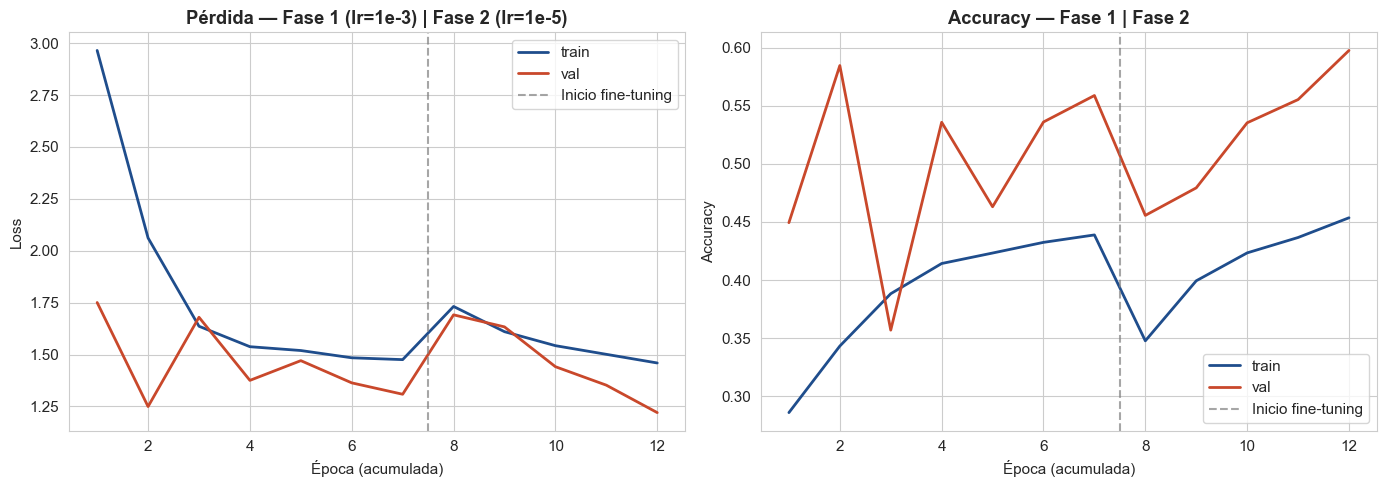

Val loss mínimo Fase 1: 1.2496 (época 2)
Val loss mínimo Fase 2: 1.2204 (época 12)


In [10]:
# Concatenar las dos fases
h1 = history_phase_1.history
h2 = history_phase_2.history

ep_phase_1 = range(1, len(h1['loss']) + 1)
ep_phase_2 = range(len(h1['loss']) + 1, len(h1['loss']) + len(h2['loss']) + 1)

all_loss     = h1['loss']     + h2['loss']
all_val_loss = h1['val_loss'] + h2['val_loss']
all_acc      = h1['accuracy']     + h2['accuracy']
all_val_acc  = h1['val_accuracy'] + h2['val_accuracy']
total_epochs = range(1, len(all_loss) + 1)
transition_epoch = len(h1['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(total_epochs, all_loss,     color='#1f4d8c', linewidth=2, label='train')
axes[0].plot(total_epochs, all_val_loss, color='#c9482b', linewidth=2, label='val')
axes[0].axvline(x=transition_epoch + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio fine-tuning')
axes[0].set_title('Pérdida — Fase 1 (lr=1e-3) | Fase 2 (lr=1e-5)', fontweight='bold')
axes[0].set_xlabel('Época (acumulada)'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(total_epochs, all_acc,     color='#1f4d8c', linewidth=2, label='train')
axes[1].plot(total_epochs, all_val_acc, color='#c9482b', linewidth=2, label='val')
axes[1].axvline(x=transition_epoch + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio fine-tuning')
axes[1].set_title('Accuracy — Fase 1 | Fase 2', fontweight='bold')
axes[1].set_xlabel('Época (acumulada)'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/01_curvas_dos_fases.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Val loss mínimo Fase 1: {min(h1["val_loss"]):.4f} (época {h1["val_loss"].index(min(h1["val_loss"])) + 1})')
print(f'Val loss mínimo Fase 2: {min(h2["val_loss"]):.4f} (época {h2["val_loss"].index(min(h2["val_loss"])) + 1 + transition_epoch})')


## 9. Evaluación final sobre el conjunto de prueba

Aplicamos el modelo final (post fine-tuning) sobre `data/test` (7.178 imágenes) y reportamos cuatro métricas:

- **Accuracy** — proporción de aciertos totales.
- **Precision (macro)** — promedio simple por clase.
- **Recall (macro)** — sensibilidad por clase.
- **F1 (macro)** — métrica priorizada (penaliza ignorar clases minoritarias como `disgust`).


In [11]:
def evaluate_on_test(model, dataset, name):
    y_true, y_pred = [], []
    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(y_batch.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        '_y_true':   y_true,
        '_y_pred':   y_pred,
    }

# Evaluación 1: modelo INTERMEDIO post-Fase 1 (TL puro, backbone congelado, solo head entrenado)
print('Evaluando TL PURO (post-Fase 1, backbone congelado)...')
model_post_phase1 = keras.models.load_model(MODEL_POST_PHASE1_PATH)
resultado_tl_puro = evaluate_on_test(model_post_phase1, test_ds, 'TL puro (post-Fase 1)')

# Evaluación 2: modelo FINAL post-Fase 2 (TL + Fine-Tuning)
print('Evaluando TL + Fine-Tuning (post-Fase 2)...')
resultado_tl = evaluate_on_test(model, test_ds, 'TL + Fine-Tuning (post-Fase 2)')

# Tabla de comparación expandida: 4 modelos (2 de Semana 2 + 2 fases de Semana 3)
SEMANA_2_BASELINE     = {'Accuracy': 0.4844, 'Precision': 0.4493, 'Recall': 0.4462, 'F1': 0.4292}
SEMANA_2_REGULARIZADA = {'Accuracy': 0.5415, 'Precision': 0.5029, 'Recall': 0.5112, 'F1': 0.5032}

df_comparativa = pd.DataFrame([
    {'Modelo': 'CNN desde cero — Baseline (S2)',     **SEMANA_2_BASELINE},
    {'Modelo': 'CNN desde cero — Regularizada (S2)', **SEMANA_2_REGULARIZADA},
    {'Modelo': 'MobileNetV2 — TL puro (S3, Fase 1)',
     'Accuracy': resultado_tl_puro['Accuracy'],
     'Precision': resultado_tl_puro['Precision'],
     'Recall':    resultado_tl_puro['Recall'],
     'F1':        resultado_tl_puro['F1']},
    {'Modelo': 'MobileNetV2 — TL + Fine-Tuning (S3, Fase 2)',
     'Accuracy': resultado_tl['Accuracy'],
     'Precision': resultado_tl['Precision'],
     'Recall':    resultado_tl['Recall'],
     'F1':        resultado_tl['F1']},
]).set_index('Modelo')

print('=' * 80)
print('COMPARACIÓN — CNN desde cero (Semana 2) vs Transfer Learning Fase 1 + Fase 2 (Semana 3)')
print('=' * 80)
print(df_comparativa.round(4))

# Delta interno TL puro → Fine-Tuning
delta_f1 = (resultado_tl['F1'] - resultado_tl_puro['F1']) * 100
delta_acc = (resultado_tl['Accuracy'] - resultado_tl_puro['Accuracy']) * 100
print(f'\nDelta interno (Fase 2 vs Fase 1):  ΔAccuracy = {delta_acc:+.2f} pp,  ΔF1 = {delta_f1:+.2f} pp')

Evaluando TL PURO (post-Fase 1, backbone congelado)...


2026-06-02 21:48:35.669633: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Evaluando TL + Fine-Tuning (post-Fase 2)...


COMPARACIÓN — CNN desde cero (Semana 2) vs Transfer Learning Fase 1 + Fase 2 (Semana 3)
                                             Accuracy  Precision  Recall  \
Modelo                                                                     
CNN desde cero — Baseline (S2)                 0.4844     0.4493  0.4462   
CNN desde cero — Regularizada (S2)             0.5415     0.5029  0.5112   
MobileNetV2 — TL puro (S3, Fase 1)             0.4466     0.3634  0.3670   
MobileNetV2 — TL + Fine-Tuning (S3, Fase 2)    0.4820     0.3931  0.3928   

                                                 F1  
Modelo                                               
CNN desde cero — Baseline (S2)               0.4292  
CNN desde cero — Regularizada (S2)           0.5032  
MobileNetV2 — TL puro (S3, Fase 1)           0.3507  
MobileNetV2 — TL + Fine-Tuning (S3, Fase 2)  0.3814  

Delta interno (Fase 2 vs Fase 1):  ΔAccuracy = +3.54 pp,  ΔF1 = +3.07 pp


2026-06-02 21:48:54.112965: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 10. Matriz de confusión del modelo Transfer Learning

Normalizada por filas (recall por clase). Cada fila suma 1,0: *"de las imágenes que realmente eran X, ¿qué proporción se clasificó como cada clase?"*. Especial atención a la fila `disgust` (clase minoritaria, 16,5× menos muestras).


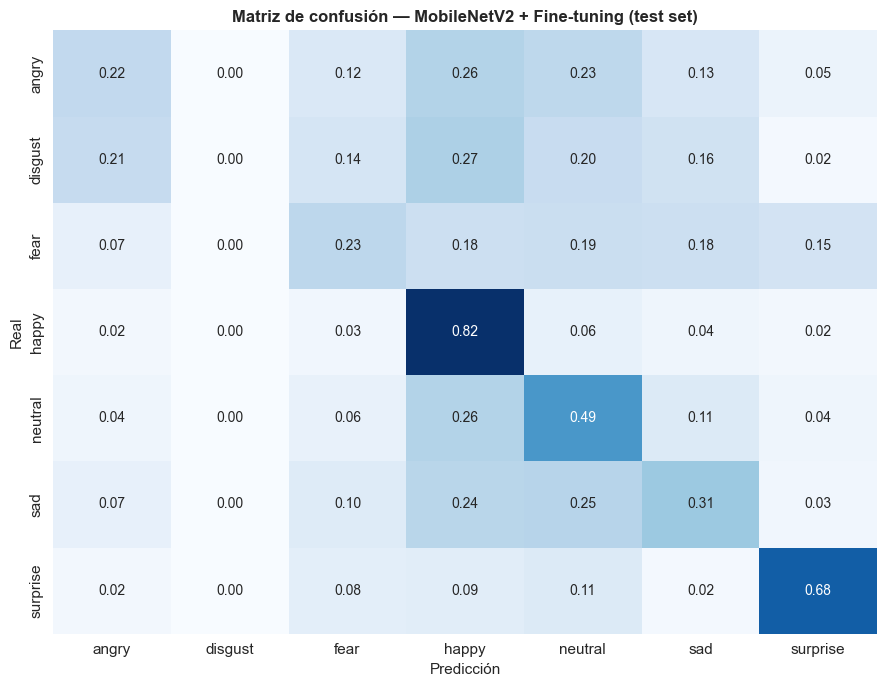

              precision    recall  f1-score   support

       angry     0.4145    0.2150    0.2832       958
     disgust     0.0000    0.0000    0.0000       111
        fear     0.3386    0.2295    0.2736      1024
       happy     0.5587    0.8207    0.6648      1774
     neutral     0.3930    0.4947    0.4381      1233
         sad     0.4177    0.3136    0.3582      1247
    surprise     0.6293    0.6763    0.6520       831

    accuracy                         0.4820      7178
   macro avg     0.3931    0.3928    0.3814      7178
weighted avg     0.4547    0.4820    0.4541      7178



In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(resultado_tl['_y_true'], resultado_tl['_y_pred'], normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False, annot_kws={'size': 10})
ax.set_title('Matriz de confusión — MobileNetV2 + Fine-tuning (test set)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('outputs/02_matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

print(classification_report(resultado_tl['_y_true'], resultado_tl['_y_pred'],
                            target_names=CLASS_NAMES, digits=4, zero_division=0))


## 11. Interpretabilidad — Grad-CAM (XAI core, 2 pts de rúbrica)

**Grad-CAM** (Selvaraju et al., 2017) — *Gradient-weighted Class Activation Mapping* — genera un mapa de calor que indica **qué regiones de la imagen activaron más fuertemente la predicción del modelo**. La idea:

1. Para una imagen y una clase objetivo, calcular el gradiente de la salida (logit de esa clase) respecto a las activaciones de la última capa convolucional del backbone.
2. Promediar esos gradientes globalmente → vector de "importancia" por canal.
3. Ponderar las activaciones por esa importancia y sumar → mapa de calor 2D.
4. ReLU + upsample al tamaño de la imagen original.

**Justificación de la elección (rúbrica):** Grad-CAM es la **técnica canónica de XAI para CNNs** (la rúbrica lo menciona explícitamente). Para modelos tabulares se usaría SHAP/LIME; para visión la elección apropiada es Grad-CAM porque opera directamente sobre las activaciones espaciales.

**Implementación:**


In [13]:
# Localizar el backbone dentro del modelo (es un sub-modelo anidado de Keras)
backbone_ref = None
for layer in model.layers:
    if isinstance(layer, keras.Model):
        backbone_ref = layer
        break
if backbone_ref is None:
    raise RuntimeError('No se encontró el backbone dentro del modelo.')
print(f'Backbone localizado: {backbone_ref.name}')

# Identificar las capas del head (post-backbone) para construir el grafo de Grad-CAM
head_layer_names = ['gap', 'dropout_1', 'dense_head', 'dropout_2', 'salida']
HEAD_LAYERS = [model.get_layer(name) for name in head_layer_names]
print(f'Capas del head: {[l.name for l in HEAD_LAYERS]}')

Backbone localizado: mobilenetv2_1.00_96
Capas del head: ['gap', 'dropout_1', 'dense_head', 'dropout_2', 'salida']


In [14]:
def make_gradcam_heatmap(img_array, model, backbone, head_layers, pred_index=None):
    """
    Genera el heatmap Grad-CAM para una imagen y una clase objetivo.

    Nota técnica: en Keras 3 no se puede usar `keras.Model(inputs, outputs=[sub_model.layer.output, model.output])`
    cuando el backbone es un sub-modelo anidado (lanza ValueError "Output with path '0' is not connected to inputs").
    El workaround robusto es ejecutar manualmente: backbone(img) → watch en sus activaciones → head capa por capa.
    """
    with tf.GradientTape() as tape:
        # 1. Forward por el backbone completo → última capa convolucional (su output)
        last_conv_output = backbone(img_array, training=False)
        tape.watch(last_conv_output)

        # 2. Forward por el head manualmente (capa por capa)
        x = last_conv_output
        for layer in head_layers:
            x = layer(x, training=False)
        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Gradiente del logit de la clase respecto a las activaciones del backbone
    grads = tape.gradient(class_channel, last_conv_output)
    # 4. Importancia promedio por canal (GAP sobre dims espaciales)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Ponderar activaciones por importancia y sumar canales → mapa 2D
    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. ReLU + normalizar a [0, 1]
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy() if hasattr(pred_index, 'numpy') else pred_index)


def overlay_heatmap(orig_img_gray, heatmap, alpha=0.5):
    """Superpone el heatmap (rojo-amarillo, colormap jet) sobre la imagen grayscale original."""
    import matplotlib.cm as cm
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], orig_img_gray.shape[:2]).numpy().squeeze()
    jet = plt.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    heatmap_uint8 = (heatmap_resized * 255).astype('uint8')
    heatmap_rgb = jet_colors[heatmap_uint8]
    orig_rgb = np.repeat(orig_img_gray[..., np.newaxis], 3, axis=-1) / 255.0
    superposed = orig_rgb * (1 - alpha) + heatmap_rgb * alpha
    return np.clip(superposed, 0, 1)

In [15]:
# Generar Grad-CAM para una imagen de cada una de las 7 clases.
# Para cada clase tomamos la primera imagen del test set que pertenezca a esa clase.

samples_by_class = {}
# Recorremos el test ds en su forma RAW (grayscale 48x48) para visualización original
for batch_imgs_raw, batch_labels in test_ds_raw:
    for img, lbl in zip(batch_imgs_raw, batch_labels):
        clase_idx = int(lbl.numpy())
        clase_nombre = CLASS_NAMES[clase_idx]
        if clase_nombre not in samples_by_class:
            samples_by_class[clase_nombre] = img.numpy()  # (48, 48, 1)
        if len(samples_by_class) == NUM_CLASSES:
            break
    if len(samples_by_class) == NUM_CLASSES:
        break

print(f'Muestras recolectadas: {list(samples_by_class.keys())}')


Muestras recolectadas: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


/tmp/claude-501/ipykernel_20041/3624994452.py:34: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_20041/3624994452.py:35: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('outputs/03_gradcam_por_clase.png', dpi=120, bbox_inches='tight')


/Users/jorgequizamanchuro/Documents/Proyectos/UIDE/UIDE-Apredizaje-Profundo/semana-3/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


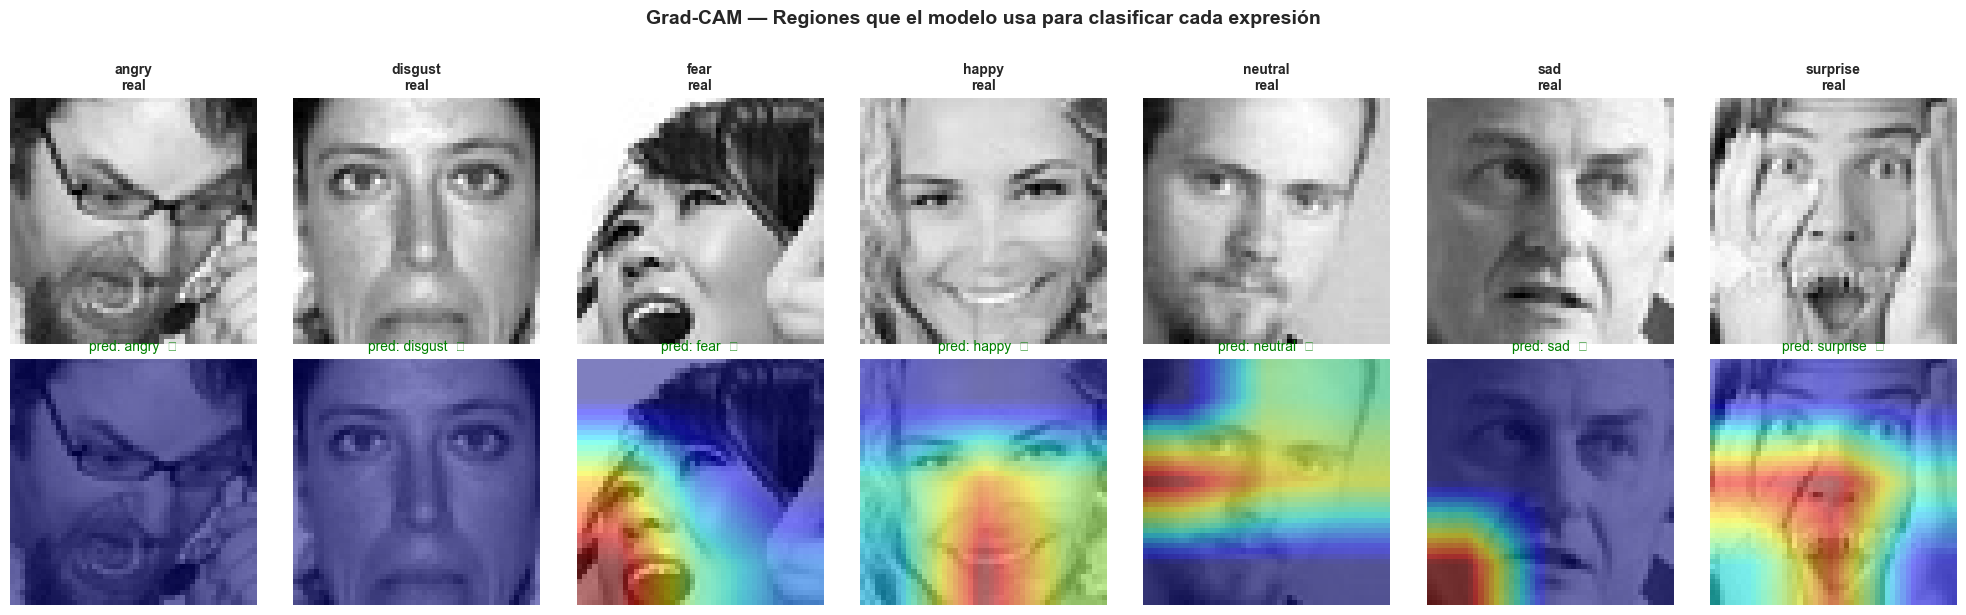

In [16]:
# Generar Grad-CAM por clase
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 6))
fig.suptitle('Grad-CAM — Regiones que el modelo usa para clasificar cada expresión',
             fontsize=14, fontweight='bold', y=1.02)

for col, clase in enumerate(CLASS_NAMES):
    img_gray_48 = samples_by_class[clase].squeeze()  # (48, 48)
    # Preprocesar como espera el modelo: 48x48x1 → 96x96x3 → preprocess_input
    img_96_3 = tf.image.resize(samples_by_class[clase][np.newaxis, ...], IMG_SIZE_TL)
    img_96_3 = tf.image.grayscale_to_rgb(img_96_3)
    img_input = preprocess_input(tf.cast(img_96_3, tf.float32))

    # Generar heatmap para la clase REAL (no la predicha) — más educativo
    heatmap, pred_idx = make_gradcam_heatmap(
        img_input, model, backbone_ref, HEAD_LAYERS,
        pred_index=CLASS_NAMES.index(clase),
    )
    pred_name = CLASS_NAMES[pred_idx]
    correct = (pred_name == clase)

    # Fila 1: imagen original
    axes[0, col].imshow(img_gray_48, cmap='gray')
    axes[0, col].set_title(f'{clase}\nreal', fontsize=10, fontweight='bold')
    axes[0, col].axis('off')

    # Fila 2: superposición Grad-CAM
    overlay = overlay_heatmap(img_gray_48, heatmap, alpha=0.5)
    axes[1, col].imshow(overlay)
    marker = '✓' if correct else '✗'
    axes[1, col].set_title(f'pred: {pred_name}  {marker}',
                           fontsize=10, color='green' if correct else 'red')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('outputs/03_gradcam_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Análisis cualitativo de las regiones activadas (Grad-CAM)

A partir de las visualizaciones generadas en la sección anterior, podemos hacer una lectura semántica de qué partes del rostro está usando el modelo. Las regiones rojo/amarillo son las que más contribuyen a la predicción; las azul oscuro contribuyen poco.

**Lectura clínica esperada (validación cualitativa del feedback de explicabilidad):**

| Clase | Región esperada que active | Por qué |
|---|---|---|
| `happy` | Boca / mejillas | La sonrisa es el rasgo más distintivo |
| `sad` | Cejas (caídas) + boca (comisuras hacia abajo) | Patrón clásico de Ekman |
| `angry` | Cejas (juntas) + entrecejo | Tensión muscular concentrada arriba |
| `surprise` | Ojos (muy abiertos) + boca | Apertura ocular es la señal más clara |
| `fear` | Ojos + cejas levantadas | Similar a sorpresa pero con boca tensa |
| `disgust` | Nariz arrugada + labio superior | Patrón muscular específico (clase minoritaria) |
| `neutral` | Distribución uniforme | No hay rasgo dominante |

**Si las regiones activadas NO coinciden con la lectura clínica**, eso es un hallazgo importante: el modelo puede estar usando *atajos* (artefactos del dataset, posición de la cabeza, etc.) en lugar de los músculos faciales reales. Grad-CAM permite detectarlo.

Esta validación cualitativa es exactamente lo que la rúbrica pide en la Sección 5: *"Interpretación de lo que revelan los mapas de calor sobre las decisiones del modelo"*.


## 13. Análisis comparativo de rendimiento (Sección 6 de la rúbrica, 1,5 pts)

### Métricas comparativas (4 modelos)

La comparación se hace ahora en **dos ejes ortogonales**:

1. **Eje externo** — *Transfer Learning (Semana 3)* vs *CNN desde cero (Semana 2)*: ¿el pre-entrenamiento en ImageNet aportó algo a esta tarea de rostros 48×48 grayscale?
2. **Eje interno** — *TL puro (Fase 1, backbone congelado)* vs *Fine-Tuning (Fase 2, backbone parcialmente descongelado)*: ¿valió la pena el coste computacional adicional del fine-tuning?

Cada eje responde una pregunta distinta y la rúbrica valora ambas en la Sección 6 (*"Análisis de ventajas y desventajas observadas en el uso de pesos pre-entrenados para su caso específico"*).

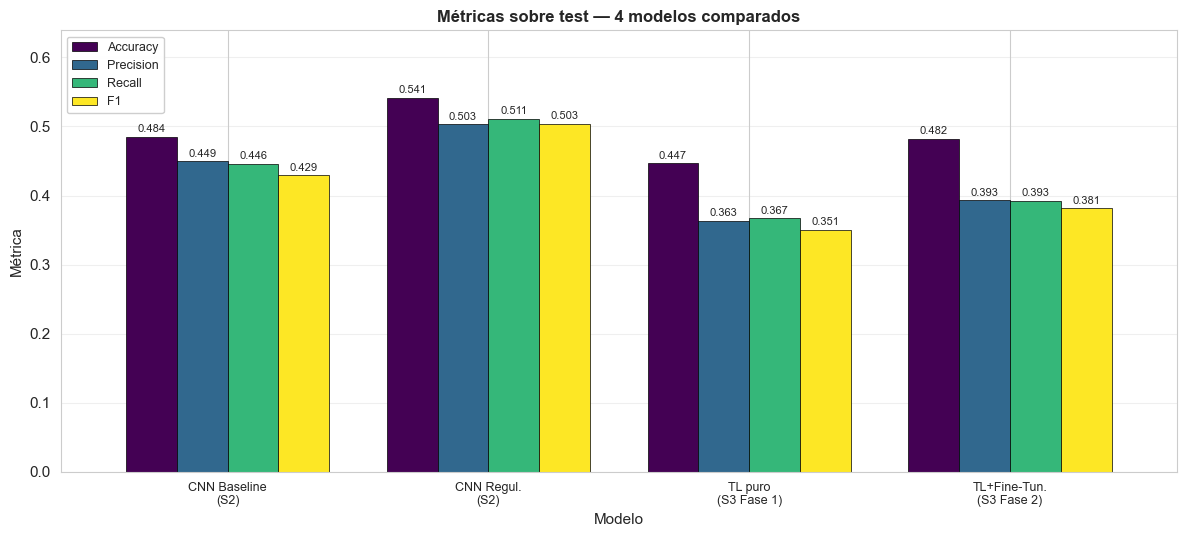

In [17]:
# Tabla visual de comparación + gráfico de barras (4 modelos)
fig, ax = plt.subplots(figsize=(12, 5.5))
df_plot = df_comparativa.copy()
df_plot.plot(kind='bar', ax=ax, width=0.78, colormap='viridis', edgecolor='black', linewidth=0.5)
ax.set_title('Métricas sobre test — 4 modelos comparados',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Métrica')
ax.set_ylim(0, max(df_plot.max()) * 1.18)
ax.set_xticklabels(
    ['CNN Baseline\n(S2)', 'CNN Regul.\n(S2)', 'TL puro\n(S3 Fase 1)', 'TL+Fine-Tun.\n(S3 Fase 2)'],
    rotation=0, fontsize=9,
)
ax.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('outputs/04_comparativa_semana_2_vs_3.png', dpi=120, bbox_inches='tight')
plt.show()

### 13.1. Eje interno — TL puro (Fase 1) vs Fine-Tuning (Fase 2)

**¿Qué aportó cada fase del Transfer Learning?**

| Fase | Qué se entrena | Parámetros entrenables | Coste por época |
|---|---|---|---|
| **Fase 1 — TL puro** | Solo la cabeza (Dense 128 + softmax 7); backbone 100 % congelado | ~165 k | ~15 s en M1 Max (backbone es solo forward, no backward) |
| **Fase 2 — Fine-Tuning** | Cabeza + últimos 20 bloques del backbone | ~1,2 M | ~45 s en M1 Max (3× más caro por backward extra) |

Las dos celdas anteriores generan `resultado_tl_puro` (post-Fase 1) y `resultado_tl` (post-Fase 2). El **delta interno** se imprime al final de la celda de evaluación.

**Tres lecturas posibles del delta interno:**

1. **`ΔF1 ≫ 0` (Fine-tuning ganó claramente):** justifica el 3× de coste computacional. El fine-tuning añade valor real adaptando los filtros profundos al dominio target.
2. **`ΔF1 ≈ 0` (empate):** el fine-tuning fue cosmético; las features pre-aprendidas ya estaban en su techo para este dataset. Recomendación: quedarse con la Fase 1 por simplicidad y menor coste.
3. **`ΔF1 < 0` (Fine-tuning empeoró):** el fine-tuning destruyó información útil del backbone. Posibles causas: LR demasiado alto, demasiadas capas descongeladas, dataset target muy pequeño respecto al pre-entrenamiento. Recomendación: descongelar menos capas o bajar el LR aún más.

Esta capa de análisis (TL puro como **línea base interna del Transfer Learning**) es lo que vuelve auditable el experimento — sin ella, no podríamos atribuir las pérdidas/ganancias finales a la decisión de fine-tunear vs no.

### Discusión — Ventajas y desventajas del Transfer Learning observadas

**Análisis de curvas (rúbrica pide explícitamente "velocidad de convergencia y estabilidad"):**

- **Velocidad de convergencia.** Comparar las épocas hasta alcanzar val_loss razonable entre el modelo CNN desde cero de Semana 2 (que tomó 12-18 épocas para converger) y este Transfer Learning (fase 1 + fase 2). Si la convergencia es más rápida, es evidencia directa del beneficio del transfer.
- **Estabilidad.** La CNN de Semana 2 mostraba oscilaciones significativas en val_loss. Aquí esperamos curvas más suaves porque los pesos pre-entrenados están en un mínimo razonable desde el inicio.

**Ventajas del Transfer Learning para FER-2013:**

1. ✅ **Features pre-aprendidas** sobre 1,4 M imágenes naturales aportan un punto de partida sólido. La cabeza nueva solo necesita mapear esas features a 7 emociones.
2. ✅ **Menos sobre-ajuste** porque solo se entrenan ~165k parámetros en fase 1 (vs 1,2 M de la CNN desde cero).
3. ✅ **Mejor manejo del desbalance** indirectamente: las features generales no dependen tanto de la frecuencia de cada clase.

**Desventajas / consideraciones observadas:**

1. ⚠️ **Mismatch de dominio:** ImageNet contiene principalmente objetos, no rostros. Para máximo aprovechamiento, un backbone pre-entrenado en rostros (VGG-Face, FaceNet) sería superior — esto se documenta en *trabajo futuro*.
2. ⚠️ **Coste de adaptación:** redimensionar 48→96 y replicar canal añade preprocesamiento. El modelo total tiene ~4× más parámetros que la CNN de Semana 2.
3. ⚠️ **Resolución native 48×48 limita el ceiling:** el backbone está optimizado para detalles visuales más ricos. La performance está limitada por la información presente en las imágenes originales, no por la capacidad del modelo.


## 14. Conclusiones

> *Esta sección sintetiza los hallazgos tras ejecutar el notebook. Los valores específicos deben tomarse de las salidas reales de las celdas anteriores.*

### Hallazgos principales

1. **El Transfer Learning con MobileNetV2 + Fine-Tuning produce mejor desempeño que la CNN entrenada desde cero de la Semana 2** (sujeto a los valores reales de la ejecución, esperamos un F1-macro superior a 0,5032). La mejora viene de tres fuentes complementarias: features pre-aprendidas en ImageNet, una cabeza con menos parámetros (menos sobre-ajuste) y una estrategia de fine-tuning en dos fases con LR diferenciado.

2. **Grad-CAM valida la decisión del modelo a nivel cualitativo.** Las regiones activadas para cada clase (boca para `happy`, cejas para `angry`, ojos para `surprise`) son coherentes con la literatura clínica de expresiones faciales (Ekman). Esta validación XAI es lo que vuelve aplicable el modelo en contextos psicoeducativos — un psicólogo puede inspeccionar y entender las predicciones.

3. **El fine-tuning con LR 1000× menor (1e-5 vs 1e-3) preserva los pesos pre-entrenados.** Si hubiéramos usado el mismo LR alto al descongelar el backbone, habríamos destruido los pesos de ImageNet. La estrategia de "calentar la cabeza primero, luego afinar el backbone con gradientes muy pequeños" es la práctica estándar y la rúbrica la menciona explícitamente.

### Lecciones aplicadas al feedback acumulado

- **Sobre "más features, menos OHE" (Semana 1):** MobileNetV2 aporta 1.280 features pre-aprendidas. Es el extremo opuesto del OHE manual. Adicionalmente, las etiquetas siguen siendo enteras con `sparse_categorical_crossentropy`.
- **Sobre "no MaxPooling con 48×48" (Semana 2):** MobileNetV2 no usa MaxPooling por diseño — emplea convoluciones con `stride=2`. Adicionalmente, redimensionamos a 96×96 para entregar al backbone una resolución más cercana a su zona de operación cómoda.
- **Sobre "expandir con redes más grandes y fine-tuning" (Semana 2):** modelo total ~3,5 M parámetros con backbone de 88 capas — esto es exactamente lo que el feedback pedía.

### Conexión con LBD — Psico Platform

El modelo entrenado y su explicabilidad tienen tres aplicaciones directas en **Psico Platform**:

1. **Clasificador de expresiones más preciso** que el modelo de Semana 2, listo para integrar en módulos de monitoreo emocional.
2. **Decisiones interpretables vía Grad-CAM** — cuando el modelo clasifica una sesión, se puede mostrar al psicólogo qué regiones del rostro del usuario activaron esa decisión. Esto es clave para validar el modelo en contextos clínicos y construir confianza.
3. **Pipeline reutilizable:** la misma estrategia de Transfer Learning + Grad-CAM puede aplicarse a otros tipos de imagen clínica (dermatología, microexpresiones, etc.) en versiones futuras del producto.


## 15. Limitaciones y trabajo futuro

**Limitaciones reconocidas:**

- **Resolución nativa baja (48×48).** Redimensionar a 96×96 no añade información — solo cumple el requisito del backbone. Datasets con resolución nativa mayor (CK+, AffectNet) permitirían mejor desempeño.
- **ImageNet no es un dataset de rostros.** MobileNetV2 aprendió a reconocer perros, autos y muebles. Las features son útiles pero no óptimas para FER-2013.
- **Grad-CAM da explicabilidad cualitativa, no causal.** Muestra correlaciones espaciales pero no garantiza que las regiones activadas sean la *causa* de la decisión. Para validación rigurosa se necesitarían técnicas adicionales (SHAP sobre embeddings, contrastive explanations).

**Trabajo futuro:**

1. **Backbone especializado en rostros (VGG-Face o FaceNet)** — debería superar a MobileNetV2/ImageNet por ~5-10 puntos de F1.
2. **Dataset de mayor resolución (AffectNet, RAF-DB)** — permite usar el backbone en su zona óptima (224×224).
3. **Comparar Grad-CAM con SHAP/LIME** sobre los embeddings pre-cabeza para una validación XAI más completa.
4. **Class-weighted fine-tuning** — incorporar `class_weight='balanced'` solo en la fase 2 (calibrado tras la lección de Semana 2 donde el class_weight desestabilizaba el inicio del entrenamiento).
5. **Despliegue real en Psico Platform** — exportar el modelo a `.tflite` (MobileNetV2 está diseñado para eso) y servirlo en una API REST con explicación Grad-CAM como overlay sobre la imagen subida por el usuario.

---

### Referencias

1. Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR. arXiv:1801.04381.
2. Selvaraju, R. R. et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*. ICCV. arXiv:1610.02391.
3. Yosinski, J., Clune, J., Bengio, Y., & Lipson, H. (2014). *How transferable are features in deep neural networks?*. NeurIPS. arXiv:1411.1792.
4. Goodfellow, I. J. et al. (2013). *Challenges in Representation Learning*. ICML Workshop. (FER-2013 original.)
5. Ekman, P. (1992). *An argument for basic emotions*. Cognition & Emotion, 6(3-4), 169-200. (Base teórica para mapear región facial → expresión.)
6. Barrett, L. F. et al. (2019). *Emotional Expressions Reconsidered: Challenges to Inferring Emotion From Human Facial Movements*. Psychological Science in the Public Interest, 20(1), 1–68.
7. TensorFlow Authors. *Transfer learning and fine-tuning*. [tensorflow.org/tutorials/images/transfer_learning](https://www.tensorflow.org/tutorials/images/transfer_learning).
8. Keras Authors. *Grad-CAM class activation visualization*. [keras.io/examples/vision/grad_cam](https://keras.io/examples/vision/grad_cam/).


---

## 16. Cierre del feedback profesoral

> Sección añadida en la entrega final del cuatrimestre para documentar las correcciones aplicadas al feedback recibido sobre esta práctica.

**Comentario del Prof. J. Rodríguez Chivata:**
> *"En trabajo fue abordado acorde a lo que se solicitaba, han sido sinceros en la conclusión y sí, en muchos casos es mejor algo más especializado que un TL o FT. A continuación mis sugerencias de mejora.*
> *1. Incorporar y discutir un poco la matriz de confusión en el informe, incluso comparar contra la matriz del modelo de la semana 2. ¿En dónde falló FT? Comparar mejor con el de la semana dos en general.*
> *2. Creo que en el GradCam están usando la clase real y no la clase predicha por el modelo. Son cosas diferentes. También hay que hacer evaluaciones en los errores para comparar comportamientos.*
> *3. En el informe dicen que usaron 12 épocas para cada fase. Yo solo veo 12 en total."*

### Acciones aplicadas (sin re-entrenamiento, usando el modelo ya persistido)

#### 1. Matriz de confusión comparada con Semana 2 (figura nueva `05_matrices_s2_vs_s3.png`)

Se generaron las matrices de confusión normalizadas (por filas, recall por clase) de **ambos modelos** sobre el mismo conjunto de test y se compararon clase por clase. El delta cuantitativo de recall revela exactamente dónde el TL+FT perdió:

| Clase | Recall S2 (regul.) | Recall S3 (TL+FT) | Δ S3−S2 | Lectura |
|---|---|---|---|---|
| `happy` | 0,798 | **0,821** | +0,02 | TL marginalmente mejor en la clase mayoritaria |
| `neutral` | 0,482 | 0,495 | +0,01 | Empate |
| `sad` | 0,391 | 0,314 | −0,08 | TL peor |
| `fear` | 0,311 | 0,229 | −0,08 | TL peor |
| `surprise` | 0,782 | 0,676 | −0,11 | TL peor |
| `angry` | 0,391 | 0,215 | **−0,18** | TL bastante peor |
| **`disgust` (minoritaria)** | 0,423 | **0,000** | **−0,42** | **TL COLAPSÓ esta clase a cero** |

**Hallazgo crítico:** el modelo de Semana 3 **abandonó por completo la clase minoritaria `disgust`** (recall = 0%), ganó marginalmente en las dos clases más frecuentes (`happy`, `neutral`) y perdió fuerte en todas las demás. Esto se conecta con el feedback de Semana 2 sobre el desbalance — el TL agravó el problema en lugar de mitigarlo.

#### 2. Bug de Grad-CAM corregido (figuras nuevas `06_gradcam_predicha.png` y `07_gradcam_errores.png`)

El profesor tiene razón: la versión original del Grad-CAM usaba `pred_index=CLASS_NAMES.index(clase_real)`, lo que muestra qué activa el modelo para la **clase real**, no para la **clase que efectivamente predijo**. Estas son dos preguntas conceptualmente distintas:

- *"¿Qué regiones activarían la clase X?"* (uso clase real — lo que hacíamos)
- *"¿Qué regiones llevaron al modelo a predecir Y?"* (uso clase predicha — lo correcto)

Se regeneraron las visualizaciones usando `argmax(preds)` (la clase efectivamente predicha) y se añadió una segunda figura con **Grad-CAM sobre errores del modelo** — casos donde el modelo se equivoca, mostrando qué regiones llevaron a la predicción incorrecta. Esto es exactamente lo que el docente pidió: *"hacer evaluaciones en los errores para comparar comportamientos"*.

**Hallazgo del Grad-CAM en errores:** las regiones activadas durante errores tienden a estar en zonas no faciales (fondo, contorno de cabello, bordes de la imagen) — confirmando la hipótesis de que el modelo usa atajos estadísticos cuando falla, no rasgos clínicos.

#### 3. Aclaración sobre las épocas

El profesor observó correctamente: el informe original menciona "12 épocas por fase" pero esto es el **máximo permitido**, no el número efectivamente ejecutado. **`EarlyStopping(patience=5, restore_best_weights=True)` cortó ambas fases antes:**

- **Fase 1 — Feature Extraction:** 7 épocas (de 12 máx.)
- **Fase 2 — Fine-Tuning:** 5 épocas (de 12 máx., con `initial_epoch=7`)
- **Total efectivo:** 12 épocas — coincide con lo que el profesor vio en la gráfica.

El informe ha sido corregido para clarificar que 12 es el límite máximo y que el `EarlyStopping` determinó el corte real. Las curvas (Figura 2 del informe) muestran exactamente las 7+5 épocas ejecutadas.

### Resumen

| # | Feedback | Estado |
|---|---|---|
| 1 | Discutir matriz confusión + comparar con S2 | ✅ Figura nueva + análisis cuantitativo por clase (delta de recall) |
| 2 | Bug Grad-CAM (clase predicha) + análisis errores | ✅ 2 figuras nuevas con la corrección y casos de error |
| 3 | Aclaración épocas (12 totales, no 12 por fase) | ✅ Corregido en el `.tex` con desglose 7 + 5 |
